In [1]:
# Import required libraries for dataset handling and data manipulation
from datasets import load_dataset_builder , load_dataset
import pandas as pd
import matplotlib.pyplot as plt


# Load the dataset builder to inspect metadata without downloading the full dataset
ds_builder = load_dataset_builder("lavita/ChatDoctor-HealthCareMagic-100k")

In [2]:
ds_builder.info.description
ds_builder.info.features

{'instruction': Value('string'),
 'input': Value('string'),
 'output': Value('string')}

In [3]:
ds = load_dataset("lavita/ChatDoctor-HealthCareMagic-100k")

In [4]:
ds['train'][0]

{'instruction': "If you are a doctor, please answer the medical questions based on the patient's description.",
 'input': 'I woke up this morning feeling the whole room is spinning when i was sitting down. I went to the bathroom walking unsteadily, as i tried to focus i feel nauseous. I try to vomit but it wont come out.. After taking panadol and sleep for few hours, i still feel the same.. By the way, if i lay down or sit down, my head do not spin, only when i want to move around then i feel the whole world is spinning.. And it is normal stomach discomfort at the same time? Earlier after i relieved myself, the spinning lessen so i am not sure whether its connected or coincidences.. Thank you doc!',
 'output': 'Hi, Thank you for posting your query. The most likely cause for your symptoms is benign paroxysmal positional vertigo (BPPV), a type of peripheral vertigo. In this condition, the most common symptom is dizziness or giddiness, which is made worse with movements. Accompanying naus

In [5]:
df_train = ds['train'].to_pandas()

In [6]:
df_train.head(10)

,instruction,input,output
0,"If you are a doctor, please answer the medical...",I woke up this morning feeling the whole room ...,"Hi, Thank you for posting your query. The most..."
1,"If you are a doctor, please answer the medical...",My baby has been pooing 5-6 times a day for a ...,Hi... Thank you for consulting in Chat Doctor....
2,"If you are a doctor, please answer the medical...","Hello, My husband is taking Oxycodone due to a...","Hello, and I hope I can help you today.First, ..."
3,"If you are a doctor, please answer the medical...",lump under left nipple and stomach pain (male)...,HI. You have two different problems. The lump ...
4,"If you are a doctor, please answer the medical...",I have a 5 month old baby who is very congeste...,Thank you for using Chat Doctor. I would sugge...
5,"If you are a doctor, please answer the medical...",I am F 38 in good shape work out (do triathlon...,"Hi, From history it seems that you might be ha..."
6,"If you are a doctor, please answer the medical...","sir, MY uncle has ILD-Interstitial Lung diseas...",Thanks for your question on Chat Doctor. I can...
7,"If you are a doctor, please answer the medical...",my husband was working on a project in the hou...,Hello. It could be a blood collection due to m...
8,"If you are a doctor, please answer the medical...",hi my nine year old son had a cough and flu sy...,"Hi, If the symptoms persist that long this sug..."
9,"If you are a doctor, please answer the medical...","gyno problemsfor the past few months, I have b...",Dear Friend. Welcome to Chat Doctor. I am Chat...


                avg_len  min_len  max_len
instruction   92.000000     92.0     92.0
input        420.546632      0.0  11188.0
output       602.854036      2.0   3304.0


C:\Users\PrajwalS\AppData\Local\Temp\ipykernel_14904\675268676.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(lengths_df[col], vert=True, showfliers=True)
C:\Users\PrajwalS\AppData\Local\Temp\ipykernel_14904\675268676.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(lengths_df[col], vert=True, showfliers=True)
C:\Users\PrajwalS\AppData\Local\Temp\ipykernel_14904\675268676.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(lengths_df[col], vert=True, showfliers=True)


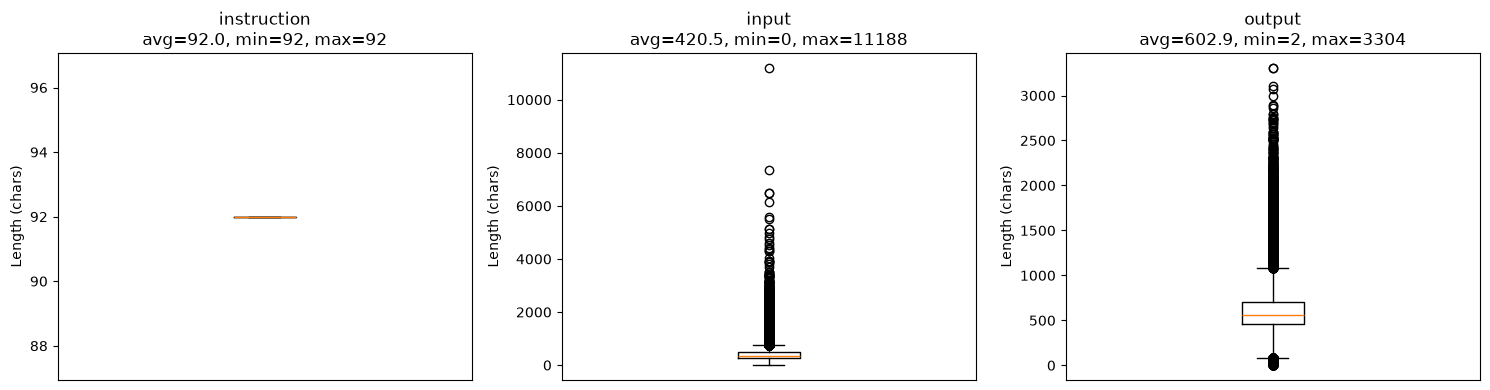

In [7]:
cols = ['instruction', 'input', 'output']

# compute lengths (handle missing values)
lengths = {c: df_train[c].fillna('').astype(str).str.len() for c in cols}
lengths_df = pd.DataFrame(lengths)

# stats: average, min, max
stats = lengths_df.agg(['mean', 'min', 'max']).T.rename(columns={'mean': 'avg_len', 'min': 'min_len', 'max': 'max_len'})
print(stats)

# boxplot for distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cols):
    ax.boxplot(lengths_df[col], vert=True, showfliers=True)
    ax.set_title(f"{col}\navg={lengths_df[col].mean():.1f}, min={int(lengths_df[col].min())}, max={int(lengths_df[col].max())}")
    ax.set_xticks([])
    ax.set_ylabel("Length (chars)")
plt.tight_layout()
plt.show()

In [8]:
# Check for empty/whitespace-only values in input and output columns
empty_input = (df_train['input'].fillna('').astype(str).str.strip() == '').sum()
empty_output = (df_train['output'].fillna('').astype(str).str.strip() == '').sum()

print(f"Rows with empty/whitespace-only 'input': {empty_input}")
print(f"Rows with empty/whitespace-only 'output': {empty_output}")


Rows with empty/whitespace-only 'input': 9
Rows with empty/whitespace-only 'output': 0


In [9]:
# rows where 'input' or 'output' are empty / whitespace-only
mask_input_empty = df_train['input'].fillna('').astype(str).str.strip() == ''
mask_output_empty = df_train['output'].fillna('').astype(str).str.strip() == ''

df_input_empty = df_train[mask_input_empty]
df_output_empty = df_train[mask_output_empty]

print(f"Input-empty rows: {len(df_input_empty)}")
print(df_input_empty)

print(f"\nOutput-empty rows: {len(df_output_empty)}")
print(df_output_empty)

Input-empty rows: 9
                                              instruction input  \
222     If you are a doctor, please answer the medical...         
16223   If you are a doctor, please answer the medical...         
19066   If you are a doctor, please answer the medical...         
27954   If you are a doctor, please answer the medical...         
66347   If you are a doctor, please answer the medical...         
81015   If you are a doctor, please answer the medical...         
84577   If you are a doctor, please answer the medical...         
90046   If you are a doctor, please answer the medical...         
105488  If you are a doctor, please answer the medical...         

                                                   output  
222     Thanks for your query, I have gone through you...  
16223   Hello, 95% of the times' fever in this age gro...  
19066   Hi, I can understand your concern. Taking an e...  
27954   Thanks for your question on Chat Doctor. I can...  
66347   H